# Gradient Descent

Gradient descent is one of the most popular algorithms to perform optimization and by far the most common way to optimize neural networks.

Gradient descent is a way to minimize an objective function $J(\theta)$ parameterized by a model's parameters $\theta \in \mathbb{R}^d$ by updating the parameters in the opposite direction of the gradient of the objective function $\nabla_\theta J(\theta)$ w.r.t. to the parameters. The learning rate $\eta$ determines the size of the steps we take to reach a (local) minimum. In other words, we follow the direction of the slope of the surface created by the objective function downhill until we reach a valley.

## Types of Gradient Descent
Gradient descent can be categorized into three types based on how much data is used to compute the gradient at each step:
1. Batch Gradient Descent: Computes the gradient using the entire dataset. This can be computationally expensive for large datasets.
2. Stochastic Gradient Descent (SGD): Computes the gradient using a single randomly selected data point. This can be noisy but allows for faster updates and can escape local minima.
3. Mini-batch Gradient Descent: Computes the gradient using a small random subset of the data (mini-batch). This is a compromise between batch and stochastic gradient descent, providing a balance between computational efficiency and convergence stability.

#### Batch Gradient Descent
In batch gradient descent, we compute the gradient of the cost function with respect to the parameters $\theta$ using the entire training dataset. The update rule is given by:
$$\theta := \theta - \eta \nabla_\theta J(\theta)$$

Parameter updating in batch gradient descent depends on the epochs. An epoch is a single pass through the entire training dataset. In batch gradient descent, we typically perform multiple epochs until convergence. So instead of updating the parameters after each data point, we update them after processing the entire dataset. This can lead to slower convergence, especially for large datasets, but it provides a more stable and accurate estimate of the gradient.

```python
for epoch in range(num_epochs):
    # Compute the gradient using the entire dataset
    gradients = compute_gradient(X, y, theta)
    
    # Update parameters
    theta -= learning_rate * gradients
```
Here the number of parameter updates is equal to the number of epochs, which is typically much smaller than the number of training examples. 

#### Stochastic Gradient Descent (SGD)
In stochastic gradient descent, we compute the gradient of the cost function with respect to the parameters $\theta$ using a single randomly selected data point at each iteration. The update rule is given by:
$$\theta := \theta - \eta \nabla_\theta J(\theta; x^{(i)}, y^{(i)})$$

where $(x^{(i)}, y^{(i)})$ is a randomly selected training example. This allows for faster updates and can help escape local minima, but it can also introduce noise into the optimization process, leading to less stable convergence.

```python
for epoch in range(num_epochs):
    for i in range(m):      # m is the number of training examples
        # Randomly select a training example
        random_index = np.random.randint(m)
        x_i = X[random_index:random_index+1]
        y_i = y[random_index:random_index+1]
        
        # Compute the gradient and update parameters
        gradients = compute_gradient(x_i, y_i, theta)
        theta -= learning_rate * gradients
```
Here the number of parameter updates is equal to the number of training examples multiplied by the number of epochs, which can be significantly larger than batch gradient descent.

#### Mini-batch Gradient Descent
In mini-batch gradient descent, we compute the gradient of the cost function with respect to the parameters $\theta$ using a small random subset of the data (mini-batch) at each iteration. The update rule is given by:
$$\theta := \theta - \eta \nabla_\theta J(\theta; X^{(i:i+b)}, y^{(i:i+b)})$$

where $X^{(i:i+b)}$ and $y^{(i:i+b)}$ are the mini-batch of training examples. This approach provides a balance between the computational efficiency of stochastic gradient descent and the stability of batch gradient descent.

```python
for epoch in range(num_epochs):
    for i in range(0, m, batch_size):
        # Create a mini-batch
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        
        # Compute the gradient and update parameters
        gradients = compute_gradient(X_batch, y_batch, theta)
        theta -= learning_rate * gradients
```
Here the number of parameter updates is equal to the number of mini-batches multiplied by the number of epochs, which is typically less than the number of updates in stochastic gradient descent but more than batch gradient descent.

`Batch Size` : The batch size is a hyperparameter that determines the number of training examples used in one iteration of gradient descent. Batch size is generally a power of 2 (e.g., 32, 64, 128) for computational efficiency reasons. If the whole dataset is used in each iteration, it is called batch gradient descent. If the batch size is 1, it is called stochastic gradient descent. If the batch size is between 1 and the total number of training examples, it is called mini-batch gradient descent. The choice of batch size can affect the convergence speed and stability of the training process.

##### Differences Between Batch Gradient Descent vs Stochastic Gradient Descent

| Aspect | Batch Gradient Descent | Stochastic Gradient Descent (SGD) |
| --- | --- | --- |
| **Data Processing** | Uses the whole training dataset to compute the gradient. | Uses a single training sample to compute the gradient. |
| **Convergence Speed** | Slower, takes longer to converge. | Faster, converges quicker due to frequent updates. |
| **Convergence Accuracy** | More accurate, gives precise gradient estimates. | Less accurate due to noisy gradient estimates. |
| **Computational and Memory Requirements** | Requires significant computation and memory. | Requires less computation and memory. |
| **Optimization of Non-Convex Functions** | Can get stuck in local minima. | Can escape local minima and find the global minimum. |
| **Suitability for Large Datasets** | Not ideal for very large datasets due to slow computation. | Can handle large datasets effectively. |
| **Nature** | Deterministic: Same result for the same initial conditions. | Stochastic: Results can vary with different initial conditions. |
| **Learning Rate** | Fixed learning rate. | Learning rate can be adjusted dynamically. |
| **Shuffling of Data** | No need for shuffling. | Requires shuffling of data before each epoch. |
| **Overfitting** | Can overfit if the model is too complex. | Can reduce overfitting due to more frequent updates. |
| **Escape Local Minima** | Cannot escape shallow local minima. | Can escape shallow local minima more easily. |
| **Computational Cost** | High due to processing the entire dataset at once. | Low due to processing one sample at a time. |
| **Final Solution** | Tends to converge to the global minimum for convex loss functions. | May converge to a local minimum or saddle point. |


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
# Create synthetic data

torch.manual_seed(42)
X = torch.randn(50, 2)

true_weights = torch.tensor([[2.0], [-3.0]])
true_bias = 1.0
y = torch.sigmoid(X @ true_weights + true_bias)
y = (y > 0.5).float()   # Convert to binary 0/1
dataset = TensorDataset(X, y)

# Simplar model definition
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Training loop
def train_model(batch_size, epochs):

    model = SimpleModel()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    total_updates = 0

    for epoch in range(epochs):
        epoch_loss = 0

        for xb, yb in loader:
            preds = model(xb)
            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            total_updates += 1

        losses.append(epoch_loss / len(loader))

    print(f"Batch Size: {batch_size}")
    print(f"Total Weight Updates: {total_updates}")
    print("-" * 40)

    return losses

In [3]:
loss_sgd = train_model(batch_size=1, epochs=5)
loss_batch = train_model(batch_size=50, epochs=5)

Batch Size: 1
Total Weight Updates: 250
----------------------------------------
Batch Size: 50
Total Weight Updates: 5
----------------------------------------


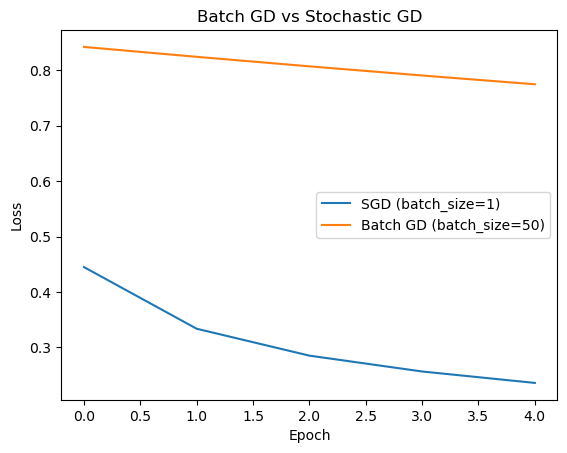

In [4]:
plt.plot(loss_sgd, label="SGD (batch_size=1)")
plt.plot(loss_batch, label="Batch GD (batch_size=50)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Batch GD vs Stochastic GD")
plt.show()